In [16]:
import numpy as np

import sys

sys.path.append("..")  # Go back to base directory

from modules.graph import *
from modules.viewer3d import *

In [17]:
def dh_transform(theta, d, a, alpha):
    """Compute individual DH transformation matrix."""
    ct, st = np.cos(theta), np.sin(theta)
    ca, sa = np.cos(alpha), np.sin(alpha)

    return np.array([
        [ct, -st * ca,  st * sa, a * ct],
        [st,  ct * ca, -ct * sa, a * st],
        [ 0,       sa,       ca,      d],
        [ 0,        0,        0,      1]
    ])

def forward_kinematics_all_frames(dh_params, joint_values):
    """
    Return a list of transformation matrices (one for each frame).
    """
    T = np.eye(4)
    frames = []  # base frame

    for i, (theta, d, a, alpha) in enumerate(dh_params):
        if theta == 'q':  # revolute
            current_theta = joint_values[i]
            current_d = d
        else:  # prismatic
            current_theta = theta
            current_d = joint_values[i]

        A_i = dh_transform(current_theta, current_d, a, alpha)
        T = T @ A_i
        frames.append(T.copy())

    return frames


In [18]:
# Example: 6-DOF arm
dh_params = [
    ('q',     0.1273,   0,        np.pi/2),
    ('q',     0.0,     -0.612,    0),
    ('q',     0.0,     -0.5723,   0),
    ('q',     0.163941, 0,        np.pi/2),
    ('q',     0.1157,   0,       -np.pi/2),
    ('q',     0.0922,   0,        0)
]

In [19]:
def square_prism_between_homogeneous(p1, p2, width):
    p1 = np.array(p1, dtype=float)
    p2 = np.array(p2, dtype=float)
    axis = p2 - p1
    length = np.linalg.norm(axis)

    if length == 0:
        raise ValueError("Points must be distinct to define a prism.")

    axis /= length

    # Orthonormal basis perpendicular to axis
    tmp = np.array([1, 0, 0]) if abs(axis[0]) < 0.99 else np.array([0, 1, 0])
    v1 = np.cross(axis, tmp)
    v1 /= np.linalg.norm(v1)

    v2 = np.cross(axis, v1)

    # Scale to half-width
    v1 *= width / 2
    v2 *= width / 2

    # Corners around p1
    corners_p1 = [
        p1 + v1 + v2,
        p1 + v1 - v2,
        p1 - v1 - v2,
        p1 - v1 + v2
    ]

    # Corners around p2
    corners_p2 = [
        p2 + v1 + v2,
        p2 + v1 - v2,
        p2 - v1 - v2,
        p2 - v1 + v2
    ]

    # Stack and convert to homogeneous coordinates
    vertices = np.array(corners_p1 + corners_p2).T  # shape (3, 8)
    homogeneous_vertices = np.vstack([vertices, np.ones((1, 8))])  # shape (4, 8)

    return homogeneous_vertices


In [20]:
def plot_robot_plotly(dh_params, joint_values, scene):
    # Compute all frame transformations
    transformations = forward_kinematics_all_frames(dh_params, joint_values)

    for i, frame in enumerate(transformations):
        # Use max of |aᵢ| and |dᵢ| to set link depth
        p = transformations[i][0:3, [-1]].flatten()

        if i != 0:
            last_p = transformations[i - 1][0:3, [-1]].flatten()

        else:
            last_p = [0, 0, 0]

        vertices = square_prism_between_homogeneous(p, last_p, 0.05)
        scene.add_solid(vertices, "")
        scene.add_frame(transformation=frame, name=f"Link {i}", axis_size=0.05, color="black")

    return scene

In [21]:
joint_values = [0, -np.pi/2, 0, 0, 0, 0]

# Create scene
scene = Viewer3D(title="UR10 Plotly Display", size=3)  # in cm

# Inertial frame
scene.add_frame(transformation=np.eye(4), name="Inertial Reference", axis_size=0.05)

# Plot robot
plot_robot_plotly(dh_params, joint_values, scene)

scene.figure.show(renderer="notebook_connected")

In [22]:
dataset_size = 10000
output_data = np.random.uniform(low=0.0, high=np.pi, size=(dataset_size, len(dh_params)))

input_data = []
for j in output_data:
    input_data.append(forward_kinematics_all_frames(dh_params, j)[-1][0:3, [-1]].flatten()[:3])

input_data = np.array(input_data)

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [24]:
class Model(nn.Module):
  def __init__(self, in_features=3, h1=400, h2=300, h3=200, h4=100, out_features=len(dh_params)):
    super().__init__()

    # Neural network structure, like literal connections to neurons
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.fc3 = nn.Linear(h2, h3)
    self.fc4 = nn.Linear(h3, h4)
    self.out = nn.Linear(h4, out_features)

  # This is the computation function, put the input, get the output
  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = F.relu(self.fc4(x))
    x = self.out(x)

    return x


In [25]:
torch.manual_seed = 42

model = Model()

In [26]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(input_data, output_data, test_size=0.2, random_state=torch.manual_seed)

x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [28]:
epochs = 500
losses = []

for i in range(epochs):
  # Use model
  y_pred = model.forward(x_train)

  # Compute loss function
  loss = criterion(y_pred, y_train)
  losses.append(loss.detach().numpy())

  # Only prints every 10 epochs
  if i % 10 == 0:
    print(f"Epoch: {i}, Loss: {loss}")

  optimizer.zero_grad() # Resets the gradient
  loss.backward() # Computes gradient of loss for each neuron
  optimizer.step() # Update weights and biases based on the gradient

Epoch: 0, Loss: 3.2364187240600586
Epoch: 10, Loss: 1.2334446907043457
Epoch: 20, Loss: 0.925693929195404
Epoch: 30, Loss: 0.847711980342865
Epoch: 40, Loss: 0.7857017517089844
Epoch: 50, Loss: 0.7475597262382507
Epoch: 60, Loss: 0.7164151072502136
Epoch: 70, Loss: 0.6846351027488708
Epoch: 80, Loss: 0.6555910706520081
Epoch: 90, Loss: 0.6133800745010376
Epoch: 100, Loss: 0.573103129863739
Epoch: 110, Loss: 0.5536803007125854
Epoch: 120, Loss: 0.5360855460166931
Epoch: 130, Loss: 0.5215247273445129
Epoch: 140, Loss: 0.509143054485321
Epoch: 150, Loss: 0.49988895654678345
Epoch: 160, Loss: 0.4931638240814209
Epoch: 170, Loss: 0.4873676896095276
Epoch: 180, Loss: 0.48182421922683716
Epoch: 190, Loss: 0.4766872525215149
Epoch: 200, Loss: 0.471830815076828
Epoch: 210, Loss: 0.4671286642551422
Epoch: 220, Loss: 0.4625810980796814
Epoch: 230, Loss: 0.4583493769168854
Epoch: 240, Loss: 0.4544753432273865
Epoch: 250, Loss: 0.45109936594963074
Epoch: 260, Loss: 0.4480854570865631
Epoch: 270, Lo

Text(0.5, 0, 'Epoch')

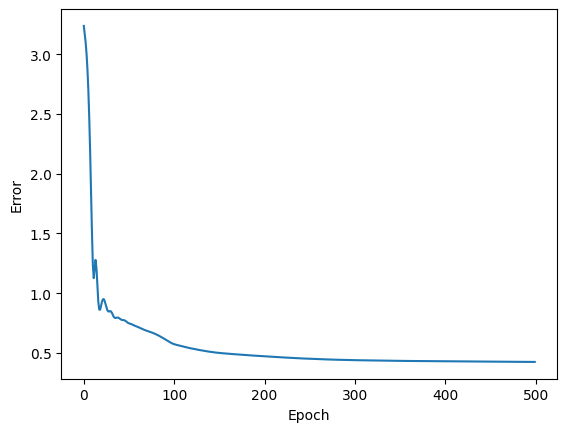

In [29]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(range(epochs), losses)
plt.ylabel("Error")
plt.xlabel("Epoch")

In [30]:
# Create scene
scene = Viewer3D(title="UR10 Plotly Display", size=3)  # in cm

joint_values = [0, -np.pi/2, -np.pi/2, np.pi/2, np.pi/2, np.pi/2]

coord = forward_kinematics_all_frames(dh_params, joint_values)[-1][0:3, [-1]].flatten()[:3]
with torch.no_grad(): # Turn off back propagation
    joints_eval = model.forward(torch.FloatTensor(np.array(coord)))

# Add inertial reference
scene.add_frame(transformation=np.eye(4), name="Inertial Reference", axis_size=40)

# Plot robot
scene = plot_robot_plotly(dh_params, joint_values, scene)

scene.add_frame(transformation=np.eye(4), name="Inertial Reference", axis_size=40)

# Plot robot
scene = plot_robot_plotly(dh_params, joints_eval, scene)

scene.figure.show(renderer="notebook_connected")